In [1]:
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import sklearn
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
from tqdm import tqdm
import torch
import torch.optim as optim
import importlib
from training2D import Trainer
from models2D import Generator, Discriminator
from os import mkdir
from tqdm.auto import tqdm
from sklearn import datasets
import sklearn
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from inf_train_gen import inf_train_gener

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [2]:
def plot_sample(samples):
    plt.hist2d(samples[:,0],samples[:,1],100)
    plt.show()

In [3]:
# Hyperparameters for matching and loading the trained model
configs = {
    "dataset": "darcy_flow",
    "momentum": 0,
    "gp_weight": 5,
    "batch_size": 512,
    "latent_dim": 2,
    "num_epochs": 10000,
    "penalty_type": "monge",
    "num_datapoints": 8190,
    "monotone_penalty": 0.0,
    "critic_iterations": 5,
    "full_critic_train": 20,
    "critic_learning_rate": 0.01,
    "gradient_penalty_type": "two_sided",
    "gen_hidden_layer_sizes": [
        128, 128, 128
    ],
    "generator_learning_rate": 0.01,
    "discriminator_hidden_layer_sizes": [
        128, 128, 128
    ],
    "device":'cuda:0'
}

In [4]:
#determine the toy distribution
print(device)
prior = 'pinwheel'
directory = './Trained_result_2D/' + prior 

cuda:0


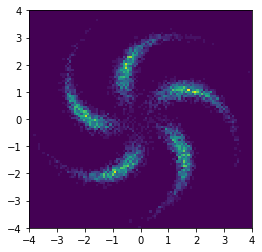

(8190, 2)


/tmp/ipykernel_440592/4277940978.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset = TensorDataset(torch.tensor(np.zeros((n,1)),dtype=torch.float), torch.tensor(X,dtype=torch.float), torch.tensor(np.zeros((n,1)),dtype=torch.float),torch.tensor(Y_org,dtype=torch.float))


In [5]:
# generate toy distribution's sample as the original sample (target distribution)
k = 5
sigma = 0.5
n = configs['num_datapoints']
Y_org = inf_train_gener(prior,batch_size = n)
plt.figure(figsize=(4, 4))
plt.hist2d(Y_org[:,0],Y_org[:,1],100,range=[[-4, 4], [-4, 4]], cmap=plt.cm.viridis)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
tick_range = np.arange(-4, 5, 1)
plt.xticks(tick_range)
plt.yticks(tick_range)
plt.savefig(directory+'/Original_sample_'+prior+'.png')
plt.show()
X = torch.randn((n, 2))
print(Y_org.shape)
dataset = TensorDataset(torch.tensor(np.zeros((n,1)),dtype=torch.float), torch.tensor(X,dtype=torch.float), torch.tensor(np.zeros((n,1)),dtype=torch.float),torch.tensor(Y_org,dtype=torch.float))
data_loader = DataLoader(dataset, batch_size=configs['batch_size'], shuffle=True)


In [6]:
condition_dim = 0
sample_dim = 2
generator_list = []


In [7]:
# import sequential generator
for i in range(k):
    generator = Generator(
        condition_dim=condition_dim,
        sample_dim=sample_dim,
        hidden_layer_sizes=[128, 128, 128], 
        sample_latent = X
        )

    discriminator = Discriminator(
        condition_dim=condition_dim,
        sample_dim=sample_dim,
        hidden_layer_sizes=[128, 128, 128], 
        )

    G_optimizer = optim.SGD(generator.parameters(), lr=configs['generator_learning_rate'],momentum = configs['momentum'])
    D_optimizer = optim.SGD(discriminator.parameters(), lr=configs['critic_learning_rate'],momentum = configs['momentum'])
    generator.load_state_dict(torch.load(directory+ '/generator_for_WGANGP-10000_'+str(i)+'.pth'))

    generator.eval()
    generator = generator.to(device)
    generator_list.append(generator)

/tmp/ipykernel_440592/3816175480.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load(directory+ '/generator_for_WGANGP-10000_'+str(i)+'

In [8]:
# define the sequential training steps as one function
def G(X, k, g_list):
    x_lat = X
    for j in range(int(k)):
        x_lat = g_list[j](x_lat.to(device))
    return x_lat

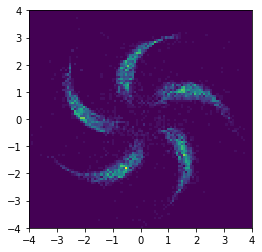

In [9]:
# generating priors 
m = configs['num_datapoints']
new_samples_y = torch.zeros((m,1))
X_latent = torch.randn((m, 2)).to(device)
Y_prior = G(X_latent,k,generator_list).cpu().detach().numpy()
plt.figure(figsize=(4, 4))
plt.hist2d(Y_prior[:,0],Y_prior[:,1],100,range=[[-4, 4], [-4, 4]], cmap=plt.cm.viridis)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
tick_range = np.arange(-4, 5, 1)
plt.xticks(tick_range)
plt.yticks(tick_range)
plt.savefig(directory+'/Generated_sample_'+prior+'.png')
plt.show()

In [10]:
# functions for weighted random picking
def compute_weights(data,A, y,sigma):
    x = np.transpose(data)
    W_tilde_array = np.zeros((n,1))
    W_array = np.zeros(n)
    for i in range(n):
        x_i = np.reshape(data[i],(2,1))
        W_tilde = np.exp(-(1/(2*sigma**2))*np.linalg.norm(A*x_i-y)**2)
        W_tilde_array[i] = W_tilde
    W_sum = np.sum(W_tilde_array)
    for j in range(n):
        W = W_tilde_array[j]/W_sum
        W_array[j]= W
    return W_array

In [11]:
# compute posterior via random choosing
def compute_posterior(Y_in):
    A = np.matrix([[1.0,0.0],[0.0,0.0]])
    x_d = np.matrix([0,0])
    x_d = np.transpose(x_d)
    y = A@x_d
    weight = compute_weights(Y_in,A,y,sigma)
    num_samples = 10000
    samples = np.transpose(Y_in)
    prob = weight.flatten() / np.sum(weight)
    resampled_indices = np.random.choice(len(prob), size=num_samples, replace=True, p=prob)
    resampled_samples = samples[:, resampled_indices]  
    return np.transpose(resampled_samples) 

/tmp/ipykernel_440592/1805449047.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W_array[j]= W


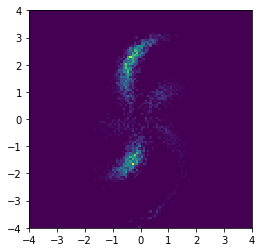

In [12]:
# plot true posterior
Y_org_sample = compute_posterior(Y_org)
plt.figure(figsize=(4, 4))
plt.hist2d(Y_org_sample[:,0], Y_org_sample[:,1], bins=(100, 100),range=[[-4, 4], [-4, 4]], cmap=plt.cm.viridis)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
tick_range = np.arange(-4, 5, 1)
plt.xticks(tick_range)
plt.yticks(tick_range)
plt.savefig(directory+'/target_sample_'+prior+'.png')
plt.show()

In [13]:
Y_posterior = compute_posterior(Y_prior)

/tmp/ipykernel_440592/1805449047.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W_array[j]= W


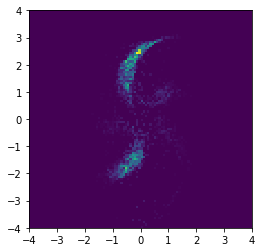

In [14]:
# plot sampled posterior
Y_sample = Y_posterior
plt.figure(figsize=(4, 4))
plt.hist2d(Y_sample[:,0],Y_sample[:,1],100,range=[[-4, 4], [-4, 4]], cmap=plt.cm.viridis)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
tick_range = np.arange(-4, 5, 1)
plt.xticks(tick_range)
plt.yticks(tick_range)
plt.savefig(directory+'/Sampled_posterior_'+prior+'.png')
plt.show()